#### Amount of dFADs in the domain 
- Using a method of going through start and end date and creating a list of dates in between 

In [53]:
import geopandas as gpd
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import xarray as xr
from functions.funcs import *

In [32]:
data = gpd.read_file(r"Data\Palmyra Data\MI_and_SAT_FAD_positions")
ds = xr.open_dataset(r"Data\cmems(3).nc")

In [23]:
mindate = data["MinOfDate"].min()
maxdate = data["MaxOfDate"].max()


In [33]:
entrydates = pd.DataFrame({"Dates":data["MinOfDate"].dt.floor('D')})
exitdates = pd.DataFrame({"Dates":data["MaxOfDate"].dt.floor('D')})
entrydates["Value"] = 1
exitdates["Value"] = -1

DateRange = pd.date_range(start = mindate,end = maxdate)
DateRange = pd.DataFrame({"Dates":DateRange})
combineddates = pd.concat([entrydates,exitdates]).sort_values("Dates")
daily_changes = combineddates.groupby('Dates')['Value'].sum().reset_index()

daily_changes = pd.merge(DateRange, daily_changes, on = "Dates", how = "left").fillna(0)
daily_changes["active_dFADs"] = daily_changes['Value'].cumsum()

In [ ]:
vo  = ds['vo'].sel(depth = 15, method = "nearest") ## this is y velocity
uo = ds['uo'].sel(depth = 15, method = "nearest")## this is x velocity

In [67]:
vtimseries = vo.mean(["latitude", "longitude"]).to_numpy()
utimseries = uo.mean(["latitude", "longitude"]).to_numpy()
speed = (vtimseries**2 +utimseries**2 )**(1/2)
speedroll = Rolling_mean(speed, 4)
meandfad = daily_changes["active_dFADs"].mean()


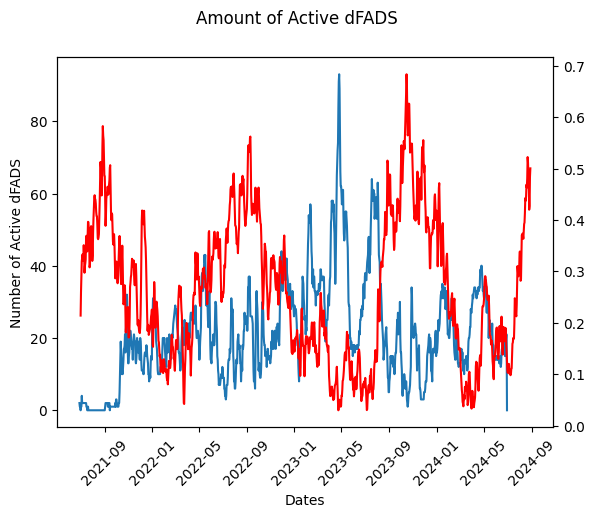

In [ ]:
fig, ax = plt.subplots()
ax.plot(daily_changes["Dates"],daily_changes["active_dFADs"])
ax2 = ax.twinx()
#ax2.plot(uo["time"], utimseries, color = "r")
#ax2.plot(vo["time"], vtimseries,color = "g" )
ax2.plot(vo["time"], speedroll, color = "r")
ax2.set_label("Speed of Ocean")
ax.set_ylabel("Number of Active dFADS")
ax.set_xlabel("Dates")
ax.set_xlim()
fig.suptitle("Amount of Active dFADS")
ax.tick_params(axis='x', labelrotation=45)

In [87]:
data.query("BuoyName == 'SLX+445898'")

,Shape_Leng,Set_3,BuoyName,Name_ID,MinOfTimes,MaxOfTimes,MinOfDate,MaxOfDate,Yr_min,Mon_min,Day_min,Yr_max,Mon_max,Day_max,Diff_days,Distance_n,geometry
2030,7.833899,2197.0,SLX+445898,445898.0,45377.534028,45420.534722,2024-03-26,2024-05-08,2024.0,3.0,26.0,2024.0,5.0,8.0,43.00,468.389509,"LINESTRING (-160.67955 4.62478, -160.68123 4.6..."
2031,0.197110,2198.0,SLX+445898,445898.0,45434.034028,45435.034028,2024-05-22,2024-05-23,2024.0,5.0,22.0,2024.0,5.0,23.0,1.00,11.768550,"LINESTRING (-163.67643 7.70863, -163.67672 7.7..."
2032,2.980660,2199.0,SLX+445898,445898.0,45459.033333,45473.867361,2024-06-16,2024-06-30,2024.0,6.0,16.0,2024.0,6.0,30.0,14.83,177.985795,"LINESTRING (-163.74698 5.86817, -163.74448 5.8..."
